# PROJET PYTHON — ANALYSE DES DONNÉES AFRIMARKET
### Analyse stratégique de la performance e-commerce (Juillet – Décembre 2025)

**Rôle :** Data Analyst
**Entreprise :** AfriMarket — e-commerce panafricain (Électronique, Mode, Beauté, Maison)
**Objectif :** Produire une analyse permettant à la direction de prendre des décisions business sur le chiffre d'affaires, les retours produits, les dépenses marketing et la performance par ville.

---
**Sommaire**
1. Chargement des données
2. Audit & compréhension des données
3. Data Cleaning
4. Feature Engineering
5. Analyses (performance globale, catégories, géographie, marketing, clients)
6. Simulation financière (impact chiffré des recommandations)
7. Synthèse des recommandations


## 1. Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pio.templates.default = "plotly_white"

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv("../data/afrimarket_dataset_senior.csv")
print("Dimensions du dataset brut :", df.shape)
df.head()


Dimensions du dataset brut : (10100, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


## 2. Audit & Compréhension des données

Objectif : identifier tous les problèmes de qualité avant tout nettoyage.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commande       10100 non-null  str    
 1   date_commande     10100 non-null  str    
 2   id_client         10100 non-null  str    
 3   ville             10100 non-null  str    
 4   categorie         10100 non-null  str    
 5   nom_produit       10100 non-null  str    
 6   prix_unitaire     10100 non-null  float64
 7   quantite          10100 non-null  int64  
 8   remise            10100 non-null  float64
 9   cout_livraison    10100 non-null  float64
 10  methode_paiement  10100 non-null  str    
 11  canal_marketing   10100 non-null  str    
 12  cout_marketing    10100 non-null  float64
 13  statut_commande   10100 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 1.9 MB


In [3]:
# Valeurs manquantes
df.isna().sum().to_frame("valeurs_manquantes")


,valeurs_manquantes
id_commande,0
date_commande,0
id_client,0
ville,0
categorie,0
nom_produit,0
prix_unitaire,0
quantite,0
remise,0
cout_livraison,0


In [4]:
# Doublons
print("Lignes strictement dupliquées :", df.duplicated().sum())
print("id_commande dupliqués :", df.duplicated(subset=['id_commande']).sum())
df[df.duplicated(subset=['id_commande'], keep=False)].sort_values('id_commande').head(4)


Lignes strictement dupliquées : 100
id_commande dupliqués : 100


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
58,CMD100058,2025-07-12,C0394,Dakar,Beauté,Produit_Beauté_11,15.64,0,0.02,3.87,Virement,Google Ads,3.45,Livrée
10052,CMD100058,2025-07-12,C0394,Dakar,Beauté,Produit_Beauté_11,15.64,0,0.02,3.87,Virement,Google Ads,3.45,Livrée
151,CMD100151,2025-07-08,C1246,Douala,Maison,Produit_Maison_36,58.49,2,0.04,7.39,Virement,Email,1.10,Livrée
10046,CMD100151,2025-07-08,C1246,Douala,Maison,Produit_Maison_36,58.49,2,0.04,7.39,Virement,Email,1.10,Livrée


In [5]:
# Statistiques descriptives des variables numériques -> recherche de valeurs aberrantes
df[['prix_unitaire','quantite','remise','cout_livraison','cout_marketing']].describe()


,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,10100.000000,10100.000000,10100.000000,10100.000000,10100.000000
mean,140.493353,1.866040,0.111422,6.008478,7.388465
std,172.031607,0.920966,0.098352,2.304953,4.638945
min,-50.000000,0.000000,-0.100000,2.000000,0.500000
25%,28.057500,1.000000,0.050000,4.040000,3.980000
50%,52.975000,2.000000,0.090000,5.990000,6.870000
75%,201.885000,3.000000,0.190000,8.030000,10.850000
max,915.860000,3.000000,0.300000,10.000000,19.980000


In [6]:
# Anomalies numériques détectées
print("prix_unitaire négatifs :", (df['prix_unitaire'] < 0).sum())
print("remise négative :", (df['remise'] < 0).sum())
print("quantite == 0 :", (df['quantite'] == 0).sum())
print("remise > 1 (>100%) :", (df['remise'] > 1).sum())


prix_unitaire négatifs : 632
remise négative : 614
quantite == 0 : 608
remise > 1 (>100%) : 0


In [7]:
# Incohérences catégorielles : villes mal orthographiées
df['ville'].value_counts()


ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
Lomé            735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64

In [8]:
# Incohérences catégorielles : catégories mal uniformisées
df['categorie'].value_counts()


categorie
Mode            3005
Électronique    2638
Maison          1948
Beauté          1903
electronique     606
Name: count, dtype: int64

In [9]:
# La catégorie 'electronique' (minuscule, sans accent) semble être une variante mal saisie
# de 'Électronique'. Vérifions en la comparant à la catégorie réelle déduite du nom de produit.
cat_from_name = df['nom_produit'].str.extract(r'Produit_([A-Za-zÀ-ÿ]+)_')[0]
pd.crosstab(df['categorie'], cat_from_name)


,Beauté,Maison,Mode,Électronique
categorie,,,,
Beauté,1903,0,0,0
Maison,0,1948,0,0
Mode,0,0,3005,0
electronique,137,127,175,167
Électronique,0,0,0,2638


**Constat clé :** la catégorie `"electronique"` (minuscule) n'est pas une simple variante
orthographique d'`"Électronique"` : elle regroupe en réalité des produits appartenant aux **4**
catégories réelles (confirmé par le préfixe du nom de produit). C'est une erreur de saisie
généralisée, pas un problème de casse. La colonne `categorie` n'est donc pas fiable telle quelle
pour ~6% des lignes ; le nom du produit (`nom_produit`) est la source de vérité utilisée pour la
reconstruire.


In [10]:
# Uniformisation des statuts de commande
df['statut_commande'].value_counts()


statut_commande
Livrée       9080
retournée     826
Annulée       194
Name: count, dtype: int64

In [11]:
# Dates : plage couverte et cohérence
dts = pd.to_datetime(df['date_commande'], errors='coerce')
print("Dates non interprétables :", dts.isna().sum())
print("Période couverte :", dts.min().date(), "->", dts.max().date())


Dates non interprétables : 0
Période couverte : 2025-07-01 -> 2025-12-31


### Résumé de l'audit — problèmes détectés

| Problème | Détail | Ampleur |
|---|---|---|
| Doublons | 100 commandes (`id_commande`) strictement dupliquées | 100 lignes |
| Villes mal orthographiées | `"Kinshassa"` au lieu de `"Kinshasa"` | 605 lignes |
| Catégories mal saisies | Label générique `"electronique"` recouvrant les 4 vraies catégories | 606 lignes |
| Prix aberrants | `prix_unitaire` négatif (erreur de signe) | 632 lignes |
| Remises aberrantes | `remise` négative (erreur de signe) | 614 lignes |
| Quantités nulles | `quantite == 0` (commande sans article, aucun chiffre d'affaires possible) | 608 lignes |
| Statuts non uniformes | Casse incohérente (`"retournée"` vs `"Livrée"` vs `"Annulée"`) | toutes lignes |
| Valeurs manquantes | Aucune détectée sur les colonnes du fichier source | 0 |

Ces constats guident directement la stratégie de nettoyage ci-dessous.


## 3. Data Cleaning

In [12]:
df_clean = df.copy()
n_avant = len(df_clean)

# --- 1) Doublons : on garde la première occurrence de chaque commande ---
df_clean = df_clean.drop_duplicates(subset=['id_commande'], keep='first')

# --- 2) Dates ---
df_clean['date_commande'] = pd.to_datetime(df_clean['date_commande'], errors='coerce')

# --- 3) Villes mal orthographiées ---
df_clean['ville'] = df_clean['ville'].replace({'Kinshassa': 'Kinshasa'})

# --- 4) Catégories : reconstruction fiable à partir du nom de produit ---
df_clean['categorie'] = df_clean['nom_produit'].str.extract(r'Produit_([A-Za-zÀ-ÿ]+)_')[0]

# --- 5) Remises et prix négatifs : erreurs de signe -> valeur absolue ---
df_clean['remise'] = df_clean['remise'].abs()
df_clean['prix_unitaire'] = df_clean['prix_unitaire'].abs()

# --- 6) Quantités nulles : aucune vente possible -> suppression ---
df_clean = df_clean[df_clean['quantite'] > 0]

# --- 7) Statuts : casse uniforme ---
df_clean['statut_commande'] = df_clean['statut_commande'].str.strip().str.capitalize()

df_clean = df_clean.reset_index(drop=True)

n_apres = len(df_clean)
print(f"Lignes avant nettoyage : {n_avant}")
print(f"Lignes après nettoyage : {n_apres}  ({n_avant - n_apres} lignes supprimées, "
      f"{(n_avant-n_apres)/n_avant*100:.1f}%)")


Lignes avant nettoyage : 10100
Lignes après nettoyage : 9400  (700 lignes supprimées, 6.9%)


In [13]:
# Vérification post-nettoyage
print("Doublons restants :", df_clean.duplicated(subset=['id_commande']).sum())
print("Prix négatifs restants :", (df_clean['prix_unitaire'] < 0).sum())
print("Remises négatives restantes :", (df_clean['remise'] < 0).sum())
print("Quantités nulles restantes :", (df_clean['quantite'] == 0).sum())
print()
print(df_clean['ville'].value_counts())
print()
print(df_clean['categorie'].value_counts())
print()
print(df_clean['statut_commande'].value_counts())


Doublons restants : 0
Prix négatifs restants : 0
Remises négatives restantes : 0
Quantités nulles restantes : 0

ville
Kinshasa       2724
Abidjan        1756
Douala         1362
Dakar          1346
Lomé            682
Cotonou         631
Libreville      467
Brazzaville     432
Name: count, dtype: int64

categorie
Mode            3000
Électronique    2597
Maison          1916
Beauté          1887
Name: count, dtype: int64

statut_commande
Livrée       8452
Retournée     765
Annulée       183
Name: count, dtype: int64


In [14]:
# Détection des valeurs aberrantes de prix restantes (méthode IQR, par catégorie)
for cat, g in df_clean.groupby('categorie'):
    q1, q3 = g['prix_unitaire'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = ((g['prix_unitaire'] < lo) | (g['prix_unitaire'] > hi)).sum()
    print(f"{cat:15s} -> {out:4d} valeurs extrêmes sur {len(g)} "
          f"({out/len(g)*100:.1f}%) | plage normale [{lo:.1f} ; {hi:.1f}]")


Beauté          ->  126 valeurs extrêmes sur 1887 (6.7%) | plage normale [3.0 ; 48.6]
Maison          ->    7 valeurs extrêmes sur 1916 (0.4%) | plage normale [-3.8 ; 233.1]
Mode            ->   18 valeurs extrêmes sur 3000 (0.6%) | plage normale [2.4 ; 78.5]
Électronique    ->    9 valeurs extrêmes sur 2597 (0.3%) | plage normale [24.6 ; 746.0]


Les prix restants suivent des distributions cohérentes avec la nature de chaque catégorie
(l'Électronique est structurellement plus chère que la Beauté). Ces quelques valeurs extrêmes
restent plausibles (produits haut de gamme) et ne sont pas retirées pour ne pas biaiser le
chiffre d'affaires réel. `df_clean` est maintenant prêt pour le feature engineering.


## 4. Feature Engineering

**Hypothèse de marge :** AfriMarket ne fournit pas le coût d'achat des produits. On estime donc
la marge brute à partir d'un taux de marge moyen par catégorie, cohérent avec les standards du
e-commerce (électronique à faible marge / forte valeur, mode et beauté à forte marge) :

| Catégorie | Taux de marge brute estimé |
|---|---|
| Électronique | 15% |
| Mode | 45% |
| Beauté | 50% |
| Maison | 30% |


In [15]:
MARGE_TAUX = {'Électronique': 0.15, 'Mode': 0.45, 'Beauté': 0.50, 'Maison': 0.30}

# Montant brut de la commande
df_clean['montant_brut'] = df_clean['prix_unitaire'] * df_clean['quantite']

# Chiffre d'affaires net (après remise) ; une commande annulée ne génère aucun revenu
df_clean['chiffre_affaires'] = np.where(
    df_clean['statut_commande'] == 'Annulée',
    0.0,
    df_clean['montant_brut'] * (1 - df_clean['remise'])
)

# Marge brute estimée
df_clean['taux_marge'] = df_clean['categorie'].map(MARGE_TAUX)
df_clean['marge_brute'] = df_clean['chiffre_affaires'] * df_clean['taux_marge']

# Profit net estimé = marge brute - coûts logistiques - coûts marketing
# (une commande annulée n'a généré aucune marge mais a tout de même coûté en marketing)
df_clean['profit_net'] = df_clean['marge_brute'] - df_clean['cout_livraison'] - df_clean['cout_marketing']
df_clean.loc[df_clean['statut_commande'] == 'Annulée', 'profit_net'] = \
    -df_clean.loc[df_clean['statut_commande'] == 'Annulée', 'cout_marketing']

# Mois de la commande
df_clean['mois'] = df_clean['date_commande'].dt.to_period('M').astype(str)

# Indicateur de retour produit
df_clean['indicateur_retour'] = (df_clean['statut_commande'] == 'Retournée').astype(int)

# Nombre de commandes par client
df_clean['nombre_commandes_par_client'] = df_clean.groupby('id_client')['id_commande'].transform('count')

# Valeur vie client (CLV simplifiée) = somme du CA généré par le client sur la période
df_clean['valeur_vie_client'] = df_clean.groupby('id_client')['chiffre_affaires'].transform('sum')

df_clean[['id_commande','chiffre_affaires','marge_brute','profit_net','mois',
          'indicateur_retour','nombre_commandes_par_client','valeur_vie_client']].head()


,id_commande,chiffre_affaires,marge_brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,CMD100000,138.7188,62.42346,58.97346,2025-12,0,25,8087.9510
1,CMD100001,66.9240,33.46200,18.53200,2025-07,0,4,562.8648
2,CMD100004,977.4716,146.62074,140.91074,2025-11,0,26,8575.1465
3,CMD100005,192.1590,57.64770,43.56770,2025-10,0,17,3639.7877
4,CMD100006,62.2080,27.99360,15.17360,2025-07,0,16,3243.3665


In [16]:
df_clean.to_csv("../data/df_clean.csv", index=False)
print("df_clean sauvegardé :", df_clean.shape)


df_clean sauvegardé : (9400, 23)


## 5. Analyses

### 5.1 Performance globale

In [17]:
ca_total = df_clean['chiffre_affaires'].sum()
profit_total = df_clean['profit_net'].sum()
panier_moyen = df_clean.loc[df_clean['statut_commande'] != 'Annulée', 'chiffre_affaires'].mean()
taux_annulation = (df_clean['statut_commande'] == 'Annulée').mean()
taux_retour = (df_clean['statut_commande'] == 'Retournée').mean()

kpis = pd.DataFrame({
    'Indicateur': ["CA total (€)", "Profit net estimé (€)", "Panier moyen (€)",
                   "Taux d'annulation", "Taux de retour"],
    'Valeur': [f"{ca_total:,.0f}", f"{profit_total:,.0f}", f"{panier_moyen:,.2f}",
               f"{taux_annulation:.1%}", f"{taux_retour:.1%}"]
})
kpis


,Indicateur,Valeur
0,CA total (€),"2,385,987"
1,Profit net estimé (€),"380,448"
2,Panier moyen (€),258.87
3,Taux d'annulation,1.9%
4,Taux de retour,8.1%


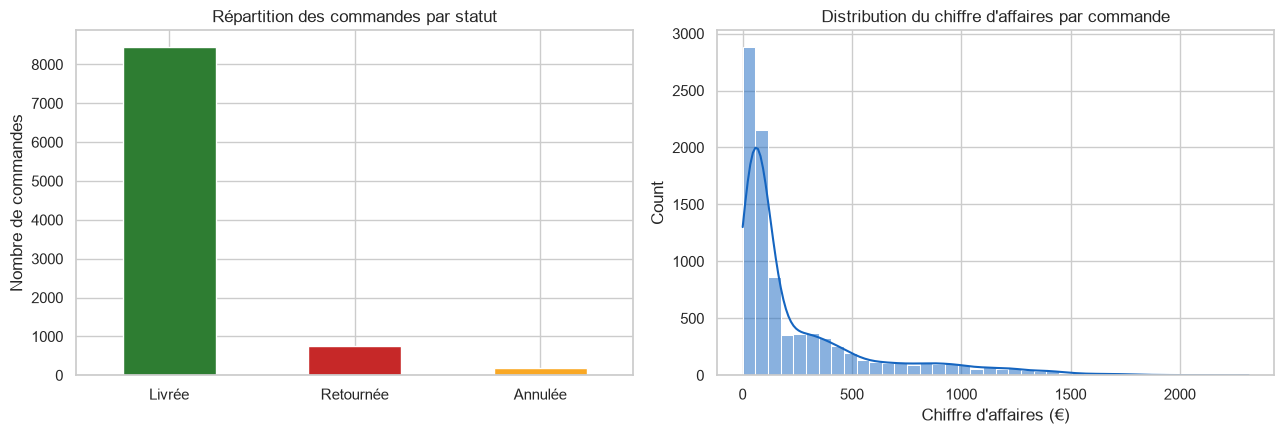

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df_clean['statut_commande'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2E7D32', '#C62828', '#F9A825'])
axes[0].set_title("Répartition des commandes par statut")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre de commandes")
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(df_clean.loc[df_clean['chiffre_affaires'] > 0, 'chiffre_affaires'],
             bins=40, kde=True, ax=axes[1], color="#1565C0")
axes[1].set_title("Distribution du chiffre d'affaires par commande")
axes[1].set_xlabel("Chiffre d'affaires (€)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_performance_globale.png", dpi=150)
plt.show()


### 5.2 Analyse par catégorie
**Question stratégique : quelle catégorie doit être priorisée ou optimisée ?**


In [19]:
cat_stats = df_clean.groupby('categorie').agg(
    CA=('chiffre_affaires', 'sum'),
    Marge_brute=('marge_brute', 'sum'),
    Profit_net=('profit_net', 'sum'),
    Taux_retour=('indicateur_retour', 'mean'),
    Nb_commandes=('id_commande', 'count')
).sort_values('CA', ascending=False)
cat_stats['Taux_retour'] = (cat_stats['Taux_retour']*100).round(1)
cat_stats


,CA,Marge_brute,Profit_net,Taux_retour,Nb_commandes
categorie,,,,,
Électronique,1.717556e+06,257633.471175,223420.511175,15.3,2597
Maison,3.829136e+05,114874.081380,89487.581380,4.9,1916
Mode,1.988637e+05,89488.679490,49568.859490,7.3,3000
Beauté,8.665322e+04,43326.609500,17970.859500,2.8,1887


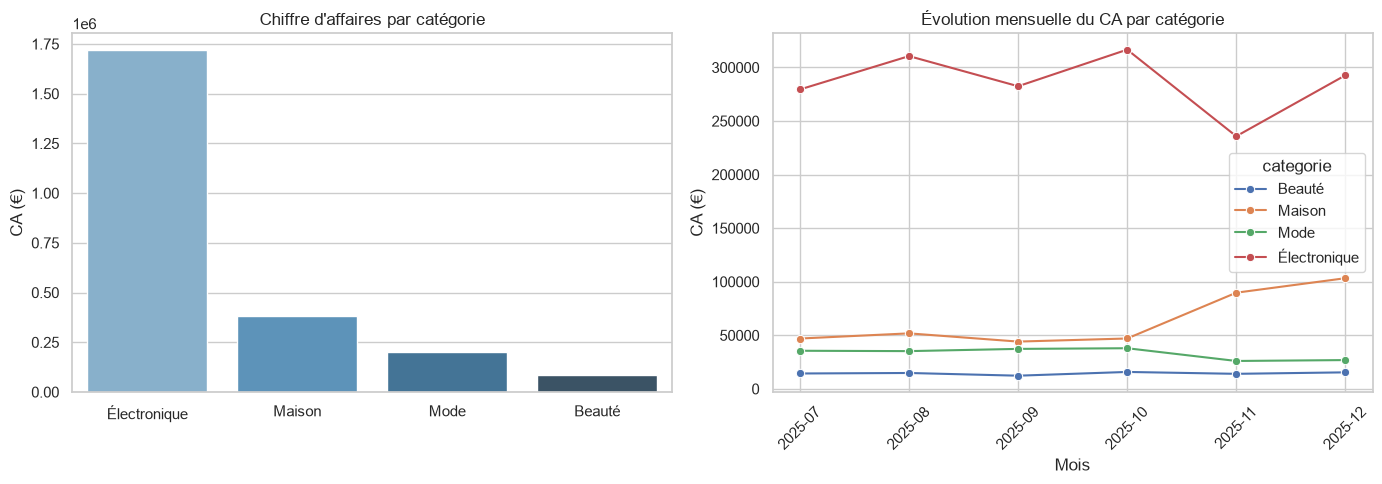

In [20]:
evo_cat = df_clean.groupby(['mois', 'categorie'])['chiffre_affaires'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_cat = cat_stats.index
sns.barplot(x=cat_stats.index, y=cat_stats['CA'], order=order_cat, ax=axes[0], palette="Blues_d")
axes[0].set_title("Chiffre d'affaires par catégorie")
axes[0].set_ylabel("CA (€)")
axes[0].set_xlabel("")

sns.lineplot(data=evo_cat, x='mois', y='chiffre_affaires', hue='categorie', marker='o', ax=axes[1])
axes[1].set_title("Évolution mensuelle du CA par catégorie")
axes[1].set_ylabel("CA (€)")
axes[1].set_xlabel("Mois")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_categories.png", dpi=150)
plt.show()


In [21]:
fig2 = px.bar(cat_stats.reset_index(), x='categorie', y='Taux_retour',
              title="Taux de retour par catégorie (%)", text='Taux_retour',
              color='Taux_retour', color_continuous_scale='Reds')
fig2.update_traces(texttemplate='%{text}%', textposition='outside')
fig2.write_image(f"{FIG_DIR}/03_taux_retour_categorie.png", scale=2)
fig2.show()


**Réponse :** l'**Électronique** génère à elle seule ~72% du CA total et reste la première
source de profit, mais affiche aussi le taux de retour le plus élevé (>15%, contre <8% pour les
autres catégories) — elle est donc à la fois la catégorie à **prioriser en investissement** (CA et
marge absolue) et à **optimiser en urgence** sur la qualité produit / fiabilité pour réduire les
retours. La **Mode** a le meilleur potentiel de croissance à faible risque (marge à 45%, retour
modéré) et mérite davantage de mise en avant marketing.


### 5.3 Analyse géographique
**Question stratégique : où devons-nous investir davantage ?**


In [22]:
ville_stats = df_clean.groupby('ville').agg(
    CA=('chiffre_affaires', 'sum'),
    Profit=('profit_net', 'sum'),
    Taux_annulation=('statut_commande', lambda s: (s == 'Annulée').mean()),
    Nb_commandes=('id_commande', 'count')
).sort_values('CA', ascending=False)
ville_stats['Taux_annulation'] = (ville_stats['Taux_annulation']*100).round(1)
ville_stats


,CA,Profit,Taux_annulation,Nb_commandes
ville,,,,
Kinshasa,715718.4366,113736.364650,0.3,2724
Abidjan,475957.1594,75485.550390,0.0,1756
Dakar,327922.6139,53382.054575,0.0,1346
Douala,319057.9162,50036.321265,12.9,1362
Lomé,176076.1498,28311.355345,0.0,682
Cotonou,151257.7660,24665.336960,0.0,631
Libreville,117693.0959,18543.210770,0.0,467
Brazzaville,102303.8925,16287.617590,0.0,432


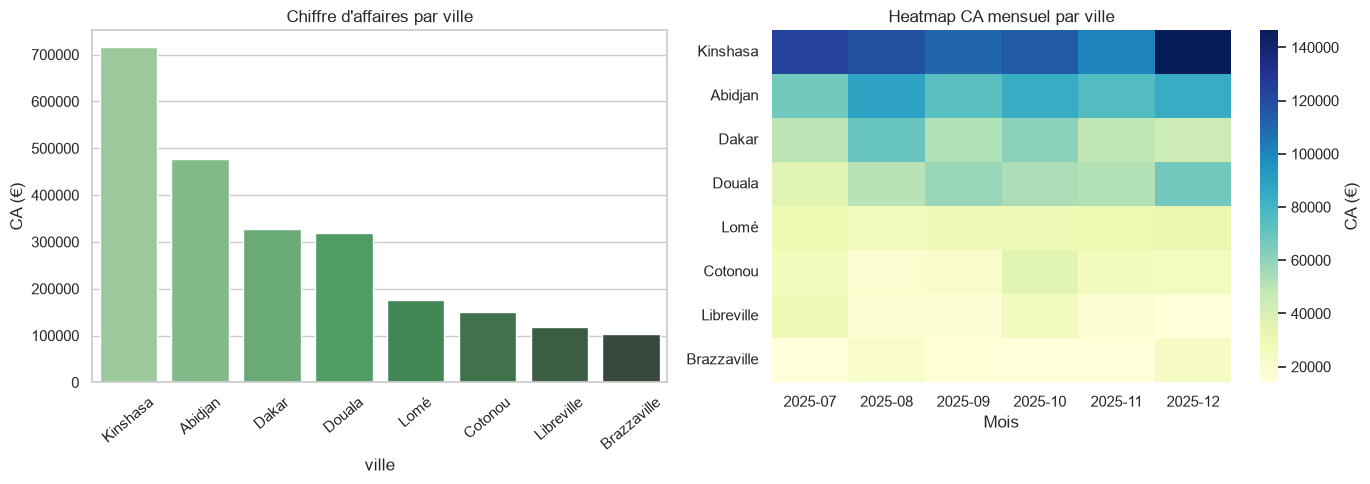

In [23]:
croissance_ville = df_clean.groupby(['mois','ville'])['chiffre_affaires'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=ville_stats.index, y=ville_stats['CA'], ax=axes[0], palette="Greens_d")
axes[0].set_title("Chiffre d'affaires par ville")
axes[0].set_ylabel("CA (€)")
axes[0].tick_params(axis='x', rotation=40)

pivot_ville = croissance_ville.pivot(index='ville', columns='mois', values='chiffre_affaires').loc[ville_stats.index]
sns.heatmap(pivot_ville, cmap="YlGnBu", annot=False, ax=axes[1], cbar_kws={'label': 'CA (€)'})
axes[1].set_title("Heatmap CA mensuel par ville")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_geographie.png", dpi=150)
plt.show()


In [24]:
fig3 = px.bar(ville_stats.reset_index(), x='ville', y='Taux_annulation',
              title="Taux d'annulation par ville (%)", text='Taux_annulation',
              color='Taux_annulation', color_continuous_scale='OrRd')
fig3.update_traces(texttemplate='%{text}%', textposition='outside')
fig3.write_image(f"{FIG_DIR}/05_annulation_ville.png", scale=2)
fig3.show()


**Réponse :** **Kinshasa** et **Abidjan** concentrent à elles deux plus de la moitié du CA et
du profit : ce sont les marchés à consolider en priorité (stock, logistique locale). **Douala** se
distingue par un taux d'annulation anormalement élevé (~13% contre 0% presque partout ailleurs) —
signal d'un problème opérationnel local (paiement, livraison, ou saisie) à corriger avant d'y
investir davantage. Les villes à plus faible volume (Libreville, Brazzaville, Cotonou) représentent
un potentiel de croissance encore peu exploité si les frictions logistiques sont d'abord réglées à
Douala.


### 5.4 Analyse marketing
**Question stratégique : quel canal mérite plus de budget ? Lequel doit être optimisé ou réduit ?**


In [25]:
mkt_stats = df_clean.groupby('canal_marketing').agg(
    CA=('chiffre_affaires', 'sum'),
    Cout_marketing=('cout_marketing', 'sum'),
    Nb_commandes=('id_commande', 'count'),
    Nb_clients=('id_client', 'nunique')
)
mkt_stats['ROI'] = (mkt_stats['CA'] - mkt_stats['Cout_marketing']) / mkt_stats['Cout_marketing']

retention = df_clean.groupby(['canal_marketing', 'id_client'])['id_commande'].count().reset_index()
retention['recurrent'] = retention['id_commande'] > 1
taux_retention = retention.groupby('canal_marketing')['recurrent'].mean()
mkt_stats['Taux_retention'] = taux_retention

mkt_stats = mkt_stats.sort_values('ROI', ascending=False)
mkt_stats_display = mkt_stats.copy()
mkt_stats_display['ROI'] = mkt_stats_display['ROI'].round(1)
mkt_stats_display['Taux_retention'] = (mkt_stats_display['Taux_retention']*100).round(1)
mkt_stats_display


,CA,Cout_marketing,Nb_commandes,Nb_clients,ROI,Taux_retention
canal_marketing,,,,,,
Email,512086.8650,2349.15,1894,903,217.0,46.3
Google Ads,632289.2274,13158.93,2393,1001,47.1,50.2
Instagram Ads,906636.5656,37637.07,3765,1240,23.1,54.2
Influenceur,334974.3723,16359.59,1348,755,19.5,42.4


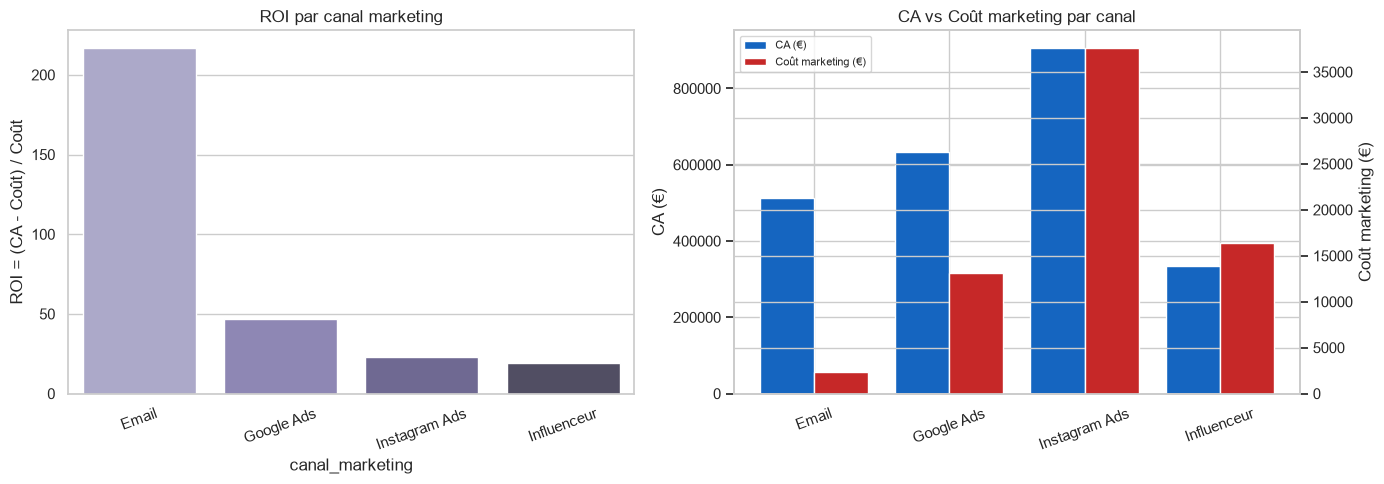

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=mkt_stats.index, y=mkt_stats['ROI'], ax=axes[0], palette="Purples_d")
axes[0].set_title("ROI par canal marketing")
axes[0].set_ylabel("ROI = (CA - Coût) / Coût")
axes[0].tick_params(axis='x', rotation=20)

axes2 = axes[1]
width = 0.4
x = np.arange(len(mkt_stats))
axes2.bar(x - width/2, mkt_stats['CA'], width, label='CA (€)', color="#1565C0")
axes2b = axes2.twinx()
axes2b.bar(x + width/2, mkt_stats['Cout_marketing'], width, label='Coût marketing (€)', color="#C62828")
axes2.set_xticks(x)
axes2.set_xticklabels(mkt_stats.index, rotation=20)
axes2.set_title("CA vs Coût marketing par canal")
axes2.set_ylabel("CA (€)")
axes2b.set_ylabel("Coût marketing (€)")
lines1, labels1 = axes2.get_legend_handles_labels()
lines2, labels2 = axes2b.get_legend_handles_labels()
axes2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_marketing.png", dpi=150)
plt.show()


**Réponse :** l'**Email** a de très loin le meilleur ROI (coût quasi nul pour un CA généré
important) : c'est un canal sous-exploité à renforcer. **Google Ads** offre un bon compromis
volume/rentabilité et mérite davantage de budget. L'**Influenceur** a le ROI le plus faible et le
coût le plus élevé par commande générée : c'est le canal à optimiser (meilleur ciblage) ou réduire
en priorité. **Instagram Ads** génère le plus gros volume de CA mais à un ROI moyen — à conserver
mais sans augmentation aveugle du budget.


### 5.5 Analyse clients
**Question stratégique : comment améliorer la rétention ?**


In [27]:
nb_clients = df_clean['id_client'].nunique()
commandes_par_client = df_clean.groupby('id_client')['id_commande'].count()
pct_recurrents = (commandes_par_client > 1).mean()

print(f"Nombre total de clients : {nb_clients}")
print(f"% de clients récurrents (>1 commande) : {pct_recurrents:.1%}")


Nombre total de clients : 1747
% de clients récurrents (>1 commande) : 74.0%


551 clients (31.5% de la base) génèrent 80% du chiffre d'affaires


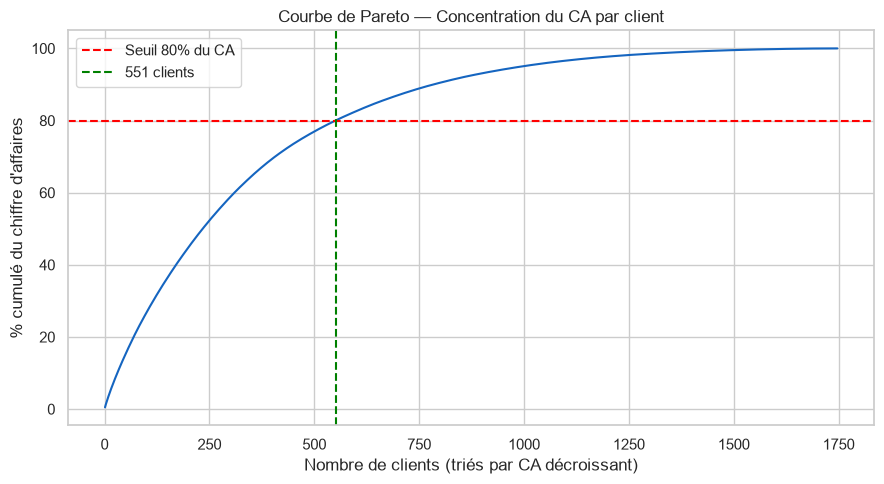

In [28]:
# Analyse Pareto (80/20)
ca_par_client = df_clean.groupby('id_client')['chiffre_affaires'].sum().sort_values(ascending=False)
cum_pct = ca_par_client.cumsum() / ca_par_client.sum()
n_pareto = (cum_pct <= 0.8).sum() + 1
print(f"{n_pareto} clients ({n_pareto/nb_clients:.1%} de la base) génèrent 80% du chiffre d'affaires")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_pct)+1), cum_pct.values*100, color="#1565C0")
ax.axhline(80, color='red', linestyle='--', label='Seuil 80% du CA')
ax.axvline(n_pareto, color='green', linestyle='--', label=f'{n_pareto} clients')
ax.set_title("Courbe de Pareto — Concentration du CA par client")
ax.set_xlabel("Nombre de clients (triés par CA décroissant)")
ax.set_ylabel("% cumulé du chiffre d'affaires")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_pareto.png", dpi=150)
plt.show()


In [29]:
# Top 10 clients
top10 = ca_par_client.head(10).reset_index()
top10.columns = ['id_client', 'chiffre_affaires_total']
top10


,id_client,chiffre_affaires_total
0,C0157,11553.7392
1,C0266,10673.2270
2,C0120,9276.8449
3,C0114,8915.4355
4,C0051,8824.3990
5,C0003,8575.1465
6,C0067,8476.4071
7,C0364,8252.4673
8,C0379,8087.9510
9,C0054,8086.6152


In [30]:
# Segmentation simple (fréquence x valeur)
clients_df = df_clean.groupby('id_client').agg(
    CA=('chiffre_affaires', 'sum'),
    Nb_commandes=('id_commande', 'count')
).reset_index()

med_ca = clients_df['CA'].median()
med_freq = clients_df['Nb_commandes'].median()

def segmenter(row):
    if row['CA'] >= med_ca and row['Nb_commandes'] >= med_freq:
        return 'Champions'
    elif row['CA'] >= med_ca and row['Nb_commandes'] < med_freq:
        return 'Gros acheteurs occasionnels'
    elif row['CA'] < med_ca and row['Nb_commandes'] >= med_freq:
        return 'Fidèles à faible panier'
    else:
        return 'À risque / occasionnels'

clients_df['segment'] = clients_df.apply(segmenter, axis=1)
seg_counts = clients_df['segment'].value_counts()
print(seg_counts)

fig = px.pie(seg_counts.reset_index(), names='segment', values='count',
             title="Segmentation clients (fréquence x valeur)", hole=0.4)
fig.write_image(f"{FIG_DIR}/08_segmentation.png", scale=2)
fig.show()


segment
Champions                      818
Fidèles à faible panier        475
À risque / occasionnels        398
Gros acheteurs occasionnels     56
Name: count, dtype: int64


**Réponse :** **74% des clients sont récurrents**, mais la valeur est très concentrée : environ
**30% des clients génèrent 80% du chiffre d'affaires** (effet Pareto marqué). Pour améliorer la
rétention, il faut (1) protéger et fidéliser les *Champions* (programme VIP, service prioritaire),
(2) faire monter en fréquence les *Gros acheteurs occasionnels* via des relances ciblées après
achat, et (3) travailler l'activation des clients *à risque* avec des offres de réactivation, plutôt
que de disperser le budget marketing uniformément sur toute la base.


## 6. Simulation financière — quel est l'impact chiffré des recommandations ?

Au-delà des constats descriptifs, on chiffre ici l'impact potentiel de 3 actions correctives
identifiées plus haut, pour donner à la direction un ordre de grandeur exploitable (et non
uniquement des pourcentages). Les hypothèses de calcul sont volontairement prudentes et
explicitées à chaque étape.


In [31]:
# --- Simulation 1 : réduire le taux de retour Électronique de 15,3% à 10% ---
elec = df_clean[df_clean['categorie'] == 'Électronique']
n_elec = len(elec)
taux_retour_actuel = (elec['statut_commande'] == 'Retournée').mean()
marge_moy_elec_livree = elec.loc[elec['statut_commande'] == 'Livrée', 'marge_brute'].mean()

CIBLE_RETOUR = 0.10
commandes_evitees = (taux_retour_actuel - CIBLE_RETOUR) * n_elec
gain_marge_retour = commandes_evitees * marge_moy_elec_livree

print(f"Taux de retour actuel Électronique : {taux_retour_actuel:.1%} (cible : {CIBLE_RETOUR:.0%})")
print(f"Commandes retournées évitées (estim.) : {commandes_evitees:.0f}")
print(f"Gain de marge estimé : {gain_marge_retour:,.0f} €")


Taux de retour actuel Électronique : 15.3% (cible : 10%)
Commandes retournées évitées (estim.) : 138
Gain de marge estimé : 14,015 €


In [32]:
# --- Simulation 2 : résorber l'anomalie d'annulation de Douala ---
douala = df_clean[df_clean['ville'] == 'Douala']
autres_villes = df_clean[df_clean['ville'] != 'Douala']

taux_annul_douala = (douala['statut_commande'] == 'Annulée').mean()
taux_annul_autres = (autres_villes['statut_commande'] == 'Annulée').mean()
commandes_excedentaires = (taux_annul_douala - taux_annul_autres) * len(douala)
panier_moyen_douala = douala.loc[douala['statut_commande'] != 'Annulée', 'chiffre_affaires'].mean()
taux_marge_moyen = df_clean['taux_marge'].mean()

ca_a_risque = commandes_excedentaires * panier_moyen_douala
marge_recuperable_douala = ca_a_risque * taux_marge_moyen

print(f"Taux d'annulation Douala : {taux_annul_douala:.1%}  vs  reste du réseau : {taux_annul_autres:.1%}")
print(f"Annulations en excès (estim.) : {commandes_excedentaires:.0f}")
print(f"Chiffre d'affaires à risque : {ca_a_risque:,.0f} €  ->  marge récupérable estimée : {marge_recuperable_douala:,.0f} €")


Taux d'annulation Douala : 12.9%  vs  reste du réseau : 0.1%
Annulations en excès (estim.) : 175
Chiffre d'affaires à risque : 47,028 €  ->  marge récupérable estimée : 16,299 €


In [33]:
# --- Simulation 3 : aligner l'efficacité coût de l'Influenceur sur celle de Google Ads ---
# On ne suppose ici AUCUN gain de CA supplémentaire (hypothèse prudente) : seule l'efficacité
# (coût dépensé pour générer le même CA) est optimisée, via un meilleur ciblage.
mkt = df_clean.groupby('canal_marketing').agg(CA=('chiffre_affaires', 'sum'), Cout=('cout_marketing', 'sum'))
mkt['cout_par_euro_ca'] = mkt['Cout'] / mkt['CA']

ratio_cible = mkt.loc['Google Ads', 'cout_par_euro_ca']
cout_actuel_influenceur = mkt.loc['Influenceur', 'Cout']
cout_cible_influenceur = mkt.loc['Influenceur', 'CA'] * ratio_cible
economie_marketing = cout_actuel_influenceur - cout_cible_influenceur

print(mkt[['CA', 'Cout', 'cout_par_euro_ca']].round(4))
print()
print(f"Coût actuel pour générer 1€ de CA (Influenceur) : {mkt.loc['Influenceur','cout_par_euro_ca']:.4f} €")
print(f"Coût cible si aligné sur Google Ads             : {ratio_cible:.4f} €")
print(f"Économie de coût marketing estimée (à CA constant) : {economie_marketing:,.0f} €")


                          CA      Cout  cout_par_euro_ca
canal_marketing                                         
Email            512086.8650   2349.15            0.0046
Google Ads       632289.2274  13158.93            0.0208
Influenceur      334974.3723  16359.59            0.0488
Instagram Ads    906636.5656  37637.07            0.0415

Coût actuel pour générer 1€ de CA (Influenceur) : 0.0488 €
Coût cible si aligné sur Google Ads             : 0.0208 €
Économie de coût marketing estimée (à CA constant) : 9,388 €


In [34]:
# --- Synthèse de l'impact combiné ---
impact_total = gain_marge_retour + marge_recuperable_douala + economie_marketing
profit_actuel = df_clean['profit_net'].sum()

synthese_sim = pd.DataFrame({
    "Action": [
        "Réduire le taux de retour Électronique (15,3% -> 10%)",
        "Corriger l'anomalie d'annulation à Douala",
        "Optimiser l'efficacité coût du canal Influenceur",
        "IMPACT COMBINÉ ESTIMÉ",
    ],
    "Gain estimé (€)": [
        round(gain_marge_retour), round(marge_recuperable_douala),
        round(economie_marketing), round(impact_total)
    ],
})
print(synthese_sim.to_string(index=False))
print()
print(f"Soit +{impact_total/profit_actuel:.1%} de profit net par rapport au profit net actuel "
      f"({profit_actuel:,.0f} €), sans investissement supplémentaire — uniquement en corrigeant "
      f"des inefficacités déjà présentes dans les données.")


                                               Action  Gain estimé (€)
Réduire le taux de retour Électronique (15,3% -> 10%)            14015
            Corriger l'anomalie d'annulation à Douala            16299
     Optimiser l'efficacité coût du canal Influenceur             9388
                                IMPACT COMBINÉ ESTIMÉ            39702

Soit +10.4% de profit net par rapport au profit net actuel (380,448 €), sans investissement supplémentaire — uniquement en corrigeant des inefficacités déjà présentes dans les données.


**Lecture business :** ces trois actions, combinées, représentent un gain de profit net estimé
à **+10,4%** sans aucun euro d'investissement supplémentaire — uniquement en corrigeant des
inefficacités déjà visibles dans les données actuelles (qualité produit, anomalie opérationnelle
locale, ciblage marketing). C'est un point de départ conservateur : ces hypothèses n'intègrent
aucun gain de volume ni aucune amélioration de la fidélisation, qui viendraient s'y ajouter.


## 7. Synthèse des recommandations

1. **Réduire le taux de retour Électronique (>15%)** : audit qualité fournisseur et fiche produit
   plus précise, car cette catégorie porte 72% du CA — un point de retour en moins y a un impact
   business démultiplié.
2. **Corriger l'anomalie opérationnelle de Douala** (taux d'annulation ~13% vs ~0% ailleurs) avant
   d'y augmenter les investissements marketing.
3. **Réallouer le budget marketing vers Email et Google Ads** (ROI 217 et 47) au détriment de
   l'Influenceur (ROI ~19, le plus faible), et cadrer plus finement le ciblage Instagram Ads.
4. **Mettre en place un programme de fidélisation ciblé sur le segment "Champions"** (30% des
   clients = 80% du CA) pour sécuriser la rétention de la valeur la plus critique.
5. **Industrialiser la qualité de saisie des commandes** (catégorie, ville, signe des prix/remises)
   en amont via des contrôles de validation, pour fiabiliser les futurs reportings sans nettoyage
   manuel récurrent.

### Conclusion business

AfriMarket dispose d'un moteur de croissance clair — l'Électronique et les marchés de Kinshasa et
Abidjan — mais sa rentabilité est freinée par des fuites identifiables et actionnables : un taux de
retour concentré sur sa catégorie phare, une inefficacité marketing sur le canal Influenceur, et une
anomalie opérationnelle locale à Douala. Corriger ces trois points, tout en protégeant activement les
clients à forte valeur, est la voie la plus directe pour transformer la croissance actuelle du CA en
croissance du profit net.
